# Aprendizaje por lotes frente a aprendizaje en línea

**Pregunta.** ¿Cuándo conviene un modelo que aprende de a una observación a la vez, frente a uno entrenado una sola vez con todos los datos?

**Datos.**

- **ALeRCE.** 40.000 objetos astronómicos del notebook 01, clasificados en periódicos, estocásticos y transitorios. Es una muestra de tamaño similar a la usada en la tesis.
- **Púlsares HTRU2.** 17.898 candidatos a púlsar del repositorio de la UCI, de los cuales solo 9% son púlsares reales.
- **Flujo simulado con cambio de concepto.** 20.000 observaciones del generador Agrawal, cuya regla de clasificación cambia a mitad del flujo.

**Método.** Los modelos por lotes se entrenan con la primera mitad del flujo y se evalúan en la segunda sin reentrenar, como un modelo puesto en producción. Los modelos en línea recorren el flujo completo prediciendo cada observación antes de aprender de ella, y se evalúan en la misma segunda mitad. Como en la tesis, la comparación central usa Naive Bayes solo, con bagging y con boosting.

**Resultado principal.** Con datos estables, el mejor modelo por lotes gana: en ALeRCE, un bosque aleatorio alcanza un F1 macro de 0,97, frente a 0,90 del mejor modelo en línea. Con Naive Bayes, ambos enfoques rinden igual. Cuando la regla del problema cambia, en cambio, los modelos por lotes quedan obsoletos y caen a menos de 50% de exactitud, mientras un árbol de Hoeffding adaptativo en línea se recupera hasta casi 100%. Además, el bagging no mejora a Naive Bayes en ningún enfoque, lo que corrige una de las apuestas de la tesis original.

## 1. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from river import compose, ensemble, forest, metrics, naive_bayes, preprocessing, tree, utils
from river.datasets import synth
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from dsaplicado import datos, en_linea
from dsaplicado.graficos import COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo

aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)

RAIZ = datos.raiz_repositorio()
CACHE = RAIZ / "datos" / "aprendizaje_en_linea"
FIGURAS = RAIZ / "04_aprendizaje_en_linea" / "figuras"
SEMILLA = 7
N_MODELOS = 10   # modelos base en bagging y boosting

def modelos_lotes():
    base = lambda modelo: make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(), modelo)
    return {
        "Naive Bayes": base(GaussianNB()),
        "Bagging de Naive Bayes": base(BaggingClassifier(GaussianNB(), n_estimators=N_MODELOS, random_state=SEMILLA)),
        "Boosting de Naive Bayes": base(AdaBoostClassifier(GaussianNB(), n_estimators=N_MODELOS, random_state=SEMILLA)),
        "Bosque aleatorio": base(RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEMILLA)),
    }

def modelos_en_linea(columnas):
    base = lambda modelo: compose.Pipeline(en_linea.imputador_en_linea(columnas), preprocessing.StandardScaler(), modelo)
    return {
        "Naive Bayes": base(naive_bayes.GaussianNB()),
        "Bagging de Naive Bayes": base(ensemble.BaggingClassifier(naive_bayes.GaussianNB(), n_models=N_MODELOS, seed=SEMILLA)),
        "Boosting de Naive Bayes": base(ensemble.AdaBoostClassifier(naive_bayes.GaussianNB(), n_models=N_MODELOS, seed=SEMILLA)),
        "Árbol de Hoeffding adaptativo": base(tree.HoeffdingAdaptiveTreeClassifier(seed=SEMILLA)),
        "Bosque aleatorio adaptativo": base(forest.ARFClassifier(n_models=N_MODELOS, seed=SEMILLA)),
    }

def comparar(X, y, metrica, cada=1000):
    mitad = len(y) // 2
    filas, curvas = {}, {}
    for nombre, modelo in modelos_lotes().items():
        r = en_linea.evaluar_lotes_congelado(modelo, X, y, mitad, metrica(), cada)
        filas[("Por lotes", nombre)] = {"métrica": r["metrica"], "segundos": r["segundos"]}
        curvas[("Por lotes", nombre)] = r["curva"]
    for nombre, modelo in modelos_en_linea(X.columns).items():
        r = en_linea.evaluar_prequential(modelo, en_linea.a_flujo(X, y), metrica(), cada, evaluar_desde=mitad)
        filas[("En línea", nombre)] = {"métrica": r["metrica"], "segundos": r["segundos"]}
        curvas[("En línea", nombre)] = r["curva"]
    tabla = pd.DataFrame(filas).T
    tabla.index.names = ["tipo", "modelo"]
    return tabla, curvas

Todos los modelos usan el mismo preprocesamiento: imputación de faltantes por la media y estandarización. En los modelos por lotes ambos pasos se ajustan con los datos de entrenamiento. En los modelos en línea, las estadísticas se actualizan a medida que llegan los datos.

## 2. ALeRCE: clasificación de objetos astronómicos

In [2]:
alerce = en_linea.cargar_alerce(CACHE)
variables = [c for c in alerce.columns if c not in ("oid", "classALeRCE", "clase_superior")]
# Muestra estratificada de 40.000 objetos en orden aleatorio fijo, que simula el orden de llegada.
muestra = (alerce.groupby("clase_superior").sample(frac=40_000 / len(alerce), random_state=SEMILLA)
           .sample(frac=1, random_state=SEMILLA).reset_index(drop=True))
X_alerce, y_alerce = muestra[variables], muestra["clase_superior"]
print(f"{len(muestra):,} objetos:", y_alerce.value_counts().to_dict())

tabla_alerce, curvas_alerce = comparar(X_alerce, y_alerce, metrics.MacroF1)
tabla_alerce.rename(columns={"métrica": "F1 macro"})

39,999 objetos: {'Periódico': 28200, 'Estocástico': 11243, 'Transitorio': 556}


F1 macro  segundos
tipo      modelo                                           
Por lotes Naive Bayes                       0.737     0.137
          Bagging de Naive Bayes            0.736     0.401
          Boosting de Naive Bayes           0.780     0.438
          Bosque aleatorio                  0.968     2.630
En línea  Naive Bayes                       0.743    17.119
          Bagging de Naive Bayes            0.749   147.560
          Boosting de Naive Bayes           0.602   225.541
          Árbol de Hoeffding adaptativo     0.876    15.107
          Bosque aleatorio adaptativo       0.895    65.012

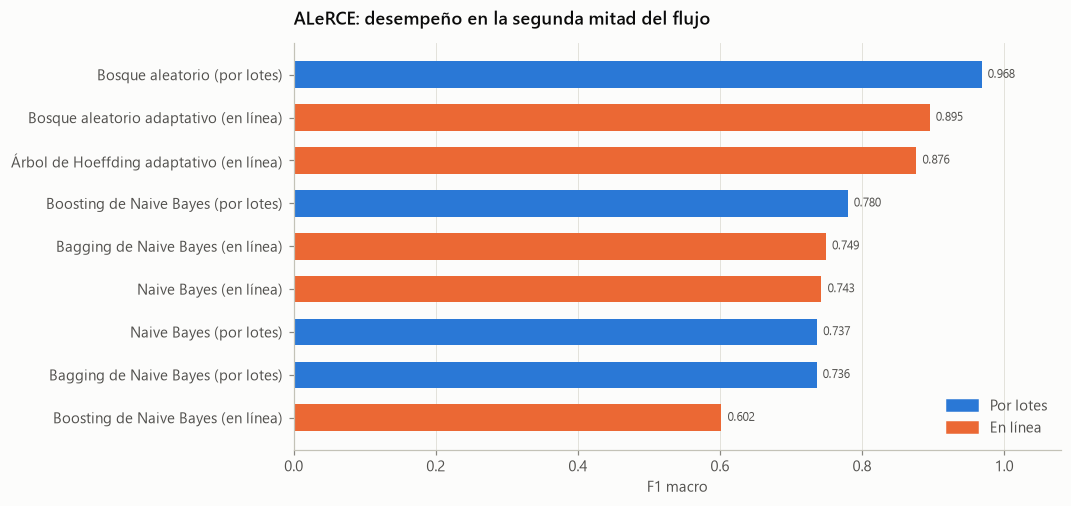

In [3]:
def grafico_barras(tabla, titulo, etiqueta, archivo=None):
    ordenada = tabla.sort_values("métrica")
    fig, ax = plt.subplots(figsize=(9, 4.8))
    colores = [COLORES[0] if tipo == "Por lotes" else COLORES[1] for tipo, _ in ordenada.index]
    nombres = [f"{modelo} ({tipo.lower()})" for tipo, modelo in ordenada.index]
    ax.barh(nombres, ordenada["métrica"], color=colores, height=0.62)
    for i, v in enumerate(ordenada["métrica"]):
        ax.annotate(f"{v:.3f}", (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8,
                    color=TINTA_SECUNDARIA)
    ax.set_xlim(0, 1.08)
    ax.set_xlabel(etiqueta)
    ax.set_title(titulo)
    ax.grid(axis="y", visible=False)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=COLORES[0], label="Por lotes"), Patch(color=COLORES[1], label="En línea")],
              loc="lower right")
    if archivo:
        fig.savefig(FIGURAS / archivo, bbox_inches="tight")
    plt.show()

grafico_barras(tabla_alerce, "ALeRCE: desempeño en la segunda mitad del flujo", "F1 macro", "resultados_alerce.png")

**Lectura.**

- **El bosque aleatorio por lotes es el mejor, con 0,97.** Con datos estables y todos disponibles de una vez, el aprendizaje por lotes aprovecha mejor la información.
- **Los árboles en línea quedan cerca.** El bosque aleatorio adaptativo llega a 0,90 y el árbol de Hoeffding a 0,88, aprendiendo de a una observación y sin guardar los datos.
- **Naive Bayes rinde igual en ambos enfoques,** con cerca de 0,74. Es esperable: Naive Bayes solo acumula medias y varianzas por clase, que se calculan igual de una vez o de a poco.
- **El bagging no ayuda a Naive Bayes.** Un modelo estable cambia poco al entrenarse con distintas muestras, así que promediar varias copias casi no mejora. Era una de las apuestas de la tesis original.
- **El boosting ayuda por lotes y perjudica en línea.** Por lotes sube a 0,78, pero en línea cae a 0,60. Una explicación probable es que el boosting en línea ajusta sus pesos con información muy temprana y ruidosa, lo que con clases desbalanceadas lo desestabiliza.

### ¿Qué pasa con los transitorios?

In [4]:
def recall_por_clase(modelo_lotes, modelo_en_linea, X, y):
    mitad = len(y) // 2
    modelo_lotes.fit(X.iloc[:mitad], y.iloc[:mitad])
    recall = {}
    for clase in sorted(y.unique()):
        mascara = y.iloc[mitad:] == clase
        recall[("Bosque aleatorio por lotes", clase)] = (modelo_lotes.predict(X.iloc[mitad:][mascara]) == clase).mean()
    aciertos, totales = {}, {}
    for k, (x, real) in enumerate(en_linea.a_flujo(X, y)):
        pred = modelo_en_linea.predict_one(x)
        if k >= mitad:
            totales[real] = totales.get(real, 0) + 1
            aciertos[real] = aciertos.get(real, 0) + (pred == real)
        modelo_en_linea.learn_one(x, real)
    for clase in totales:
        recall[("Bosque aleatorio adaptativo en línea", clase)] = aciertos[clase] / totales[clase]
    return pd.Series(recall).unstack()

recall_alerce = recall_por_clase(modelos_lotes()["Bosque aleatorio"], modelos_en_linea(X_alerce.columns)["Bosque aleatorio adaptativo"],
                                 X_alerce, y_alerce)
recall_alerce.style.format("{:.1%}")

,Estocástico,Periódico,Transitorio
Bosque aleatorio adaptativo en línea,95.6%,99.8%,59.2%
Bosque aleatorio por lotes,97.4%,99.8%,91.4%


**Lectura.** La diferencia entre ambos bosques está casi toda en la clase rara. Los dos reconocen bien a los objetos periódicos y estocásticos, pero el bosque por lotes identifica al 91% de los transitorios y el en línea solo al 59%. Con apenas unos cientos de transitorios en el flujo, el modelo en línea ve muy pocos ejemplos antes de tener que reconocerlos, mientras el modelo por lotes los estudia todos juntos.

## 3. Púlsares: una clase rara en datos reales

In [5]:
pulsar = en_linea.cargar_pulsar(CACHE).sample(frac=1, random_state=SEMILLA).reset_index(drop=True)
X_pulsar, y_pulsar = pulsar.drop(columns="pulsar"), pulsar["pulsar"]
print(f"{len(pulsar):,} candidatos, {y_pulsar.mean():.1%} púlsares")
tabla_pulsar, curvas_pulsar = comparar(X_pulsar, y_pulsar, metrics.F1)
tabla_pulsar.rename(columns={"métrica": "F1 de la clase púlsar"})

17,898 candidatos, 9.2% púlsares


F1 de la clase púlsar  segundos
tipo      modelo                                                        
Por lotes Naive Bayes                                    0.746     0.034
          Bagging de Naive Bayes                         0.747     0.075
          Boosting de Naive Bayes                        0.858     0.073
          Bosque aleatorio                               0.887     0.499
En línea  Naive Bayes                                    0.746     3.316
          Bagging de Naive Bayes                         0.745    26.901
          Boosting de Naive Bayes                        0.859    51.502
          Árbol de Hoeffding adaptativo                  0.870     2.398
          Bosque aleatorio adaptativo                    0.889    17.852

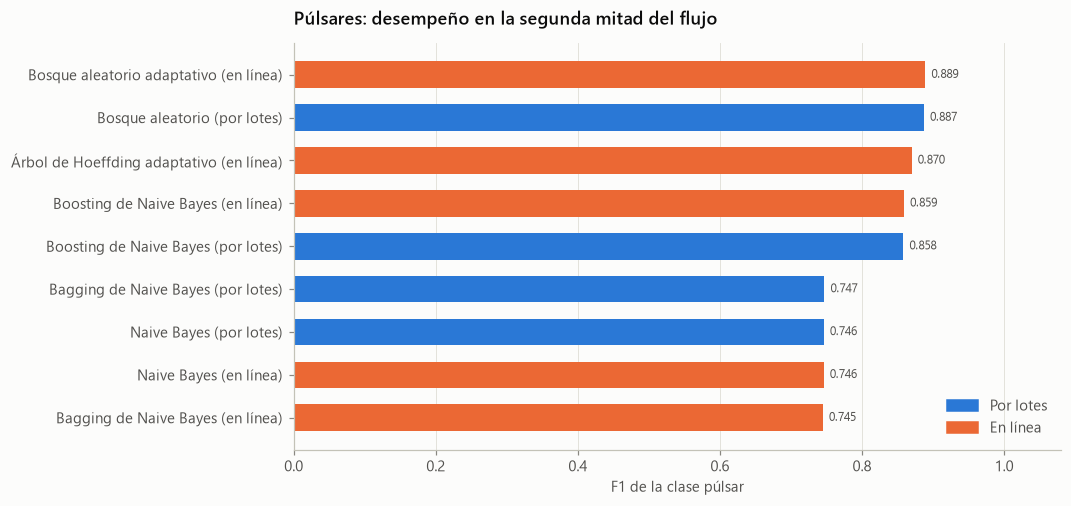

In [6]:
grafico_barras(tabla_pulsar, "Púlsares: desempeño en la segunda mitad del flujo", "F1 de la clase púlsar")

**Lectura.** Con los púlsares, los dos enfoques quedan prácticamente empatados en cada tipo de modelo. Naive Bayes rinde 0,746 en ambos, el boosting 0,86 y el mejor bosque 0,89. Aquí el boosting sí ayuda en línea, porque el problema tiene solo ocho variables y una frontera más simple. La lección es que el aprendizaje en línea no implica perder precisión: depende del modelo y del problema.

## 4. Cambio de concepto: cuando el mundo cambia

En los dos casos anteriores la relación entre variables y clases es estable. En muchos problemas reales no lo es: el comportamiento de los clientes cambia, aparece un nuevo tipo de fraude o cambia un instrumento de medición. Se simula ese caso con el generador Agrawal: a mitad del flujo, la regla que define la clase cambia por otra.

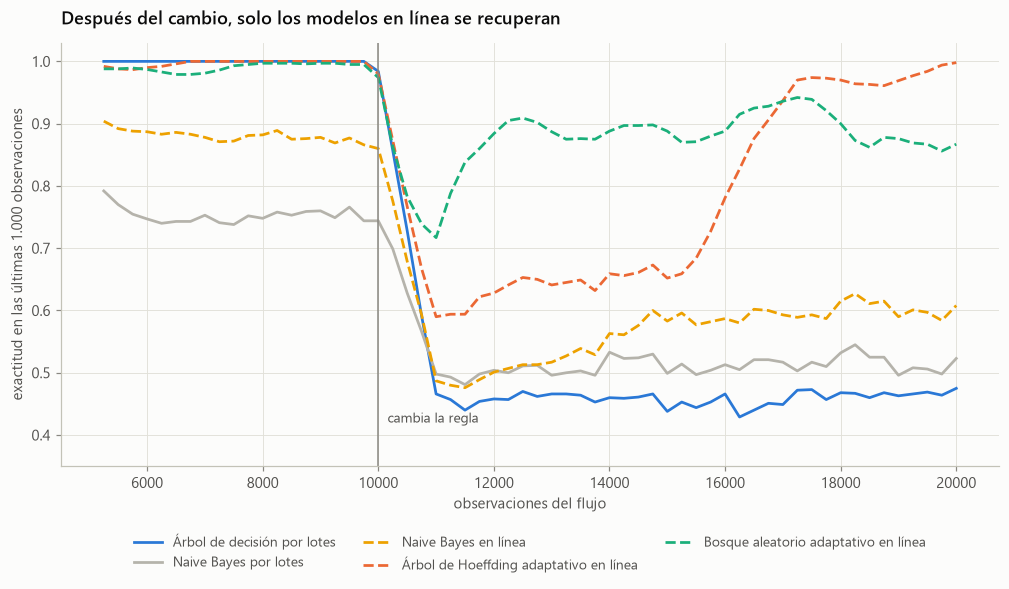

observaciones,"9,500 obs.","11,000 obs.","13,000 obs.","20,000 obs."
Árbol de decisión por lotes,1.000,0.466,0.466,0.475
Naive Bayes por lotes,0.766,0.498,0.496,0.523
Naive Bayes en línea,0.877,0.487,0.517,0.608
Árbol de Hoeffding adaptativo en línea,1.000,0.590,0.641,0.998
Bosque aleatorio adaptativo en línea,0.995,0.717,0.887,0.867


In [7]:
N_DERIVA = 20_000
flujo = list(synth.ConceptDriftStream(
    stream=synth.Agrawal(classification_function=0, seed=SEMILLA),
    drift_stream=synth.Agrawal(classification_function=2, seed=SEMILLA),
    position=N_DERIVA // 2, width=200, seed=SEMILLA).take(N_DERIVA))
X_deriva = pd.DataFrame([x for x, _ in flujo])
y_deriva = pd.Series([etiqueta for _, etiqueta in flujo])

ventana = lambda: utils.Rolling(metrics.Accuracy, window_size=1000)
curvas_deriva = {}
entrenamiento = N_DERIVA // 4
for nombre, modelo in {"Árbol de decisión por lotes": DecisionTreeClassifier(max_depth=8, random_state=SEMILLA),
                       "Naive Bayes por lotes": GaussianNB()}.items():
    curvas_deriva[nombre] = en_linea.evaluar_lotes_congelado(modelo, X_deriva, y_deriva, entrenamiento, ventana(), 250)["curva"]
for nombre, modelo in {"Naive Bayes en línea": naive_bayes.GaussianNB(),
                       "Árbol de Hoeffding adaptativo en línea": tree.HoeffdingAdaptiveTreeClassifier(seed=SEMILLA),
                       "Bosque aleatorio adaptativo en línea": forest.ARFClassifier(n_models=N_MODELOS, seed=SEMILLA)}.items():
    curvas_deriva[nombre] = en_linea.evaluar_prequential(modelo, en_linea.a_flujo(X_deriva, y_deriva), ventana(), 250,
                                                         evaluar_desde=entrenamiento)["curva"]

fig, ax = plt.subplots(figsize=(11, 5))
estilos = {"Árbol de decisión por lotes": (COLORES[0], "-"), "Naive Bayes por lotes": (NEUTRO, "-"),
           "Naive Bayes en línea": (COLORES[3], "--"), "Árbol de Hoeffding adaptativo en línea": (COLORES[1], "--"),
           "Bosque aleatorio adaptativo en línea": (COLORES[2], "--")}
for nombre, curva in curvas_deriva.items():
    color, linea = estilos[nombre]
    ax.plot(curva["observaciones"], curva["metrica"], color=color, linestyle=linea, linewidth=1.8, label=nombre)
ax.axvline(N_DERIVA // 2, color=TINTA_TENUE, linewidth=1)
ax.annotate("cambia la regla", (N_DERIVA // 2, 0.42), xytext=(6, 0), textcoords="offset points", fontsize=9,
            color=TINTA_SECUNDARIA)
ax.set_ylim(0.35, 1.03)
ax.set_xlabel("observaciones del flujo")
ax.set_ylabel("exactitud en las últimas 1.000 observaciones")
ax.set_title("Después del cambio, solo los modelos en línea se recuperan")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncols=3, fontsize=9)
fig.savefig(FIGURAS / "cambio_de_concepto.png", bbox_inches="tight")
plt.show()

hitos = pd.DataFrame({n: c.set_index("observaciones")["metrica"] for n, c in curvas_deriva.items()})
hitos.loc[[9_500, 11_000, 13_000, 20_000]].T.rename(columns=lambda v: f"{v:,} obs.")

**Lectura.**

- **Antes del cambio, los árboles aciertan casi todo,** por lotes y en línea.
- **Después del cambio, los modelos por lotes quedan obsoletos.** El árbol entrenado por lotes cae de 100% a 47% de exactitud y no se recupera, porque nadie lo reentrena.
- **El árbol de Hoeffding adaptativo detecta el cambio y se reconstruye.** Tarda unas 7.000 observaciones, pero termina en 99,8%.
- **El bosque aleatorio adaptativo reacciona más rápido,** aunque se estabiliza cerca de 87%.
- **Naive Bayes en línea se recupera solo en parte,** hasta 61%, porque sigue promediando lo aprendido antes del cambio.

## 5. Conclusiones

1. **Con datos estables, el aprendizaje por lotes sigue siendo la mejor opción.** Es más preciso y más rápido de entrenar una vez.
2. **El aprendizaje en línea no implica perder precisión en todos los modelos.** Naive Bayes y los bosques rinden parecido en ambos enfoques con los púlsares.
3. **Su gran ventaja es adaptarse a los cambios.** Cuando la regla del problema cambia, solo los modelos en línea con detección de cambios se recuperan.
4. **Las clases raras son el punto débil del aprendizaje en línea.** Con pocos ejemplos, un modelo en línea tarda en aprenderlas, como muestra el caso de los transitorios.
5. **No todo ensamble ayuda.** El bagging no mejora a Naive Bayes, y el boosting en línea puede empeorar el resultado con clases desbalanceadas.

## 6. Limitaciones

- **Orden aleatorio.** ALeRCE y los púlsares no tienen un orden temporal en estos datos, así que el flujo se simula con un orden aleatorio fijo. Con datos en orden de llegada real, los modelos en línea podrían tener más ventaja si el cielo observado cambia con la temporada.
- **Hiperparámetros por defecto.** No se ajustaron los hiperparámetros de ningún modelo. Un ajuste cuidadoso podría cambiar las distancias entre ellos, pero probablemente no el orden general.
- **Nivel superior de la jerarquía.** Solo se clasifica en tres grupos. El clasificador real de ALeRCE también asigna las 15 clases específicas.